In [ ]:
!pip install kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"swastikmanna","key":"d2a7849136394b53ec7c5e8fb82d42eb"}'}

In [2]:
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!ls -ltr /root/.kaggle

total 4
-rw------- 1 root root 68 Jan 31 08:27 kaggle.json


In [3]:
!kaggle datasets download -d fedesoriano/stellar-classification-dataset-sdss17
!unzip stellar-classification-dataset-sdss17.zip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17
License(s): copyright-authors
stellar-classification-dataset-sdss17.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  stellar-classification-dataset-sdss17.zip
replace star_classification.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: no


In [4]:
import pandas as pd

df = pd.read_csv("star_classification.csv")
df.head()


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [5]:
df['class'].value_counts()


,count
class,
GALAXY,59445
STAR,21594
QSO,18961


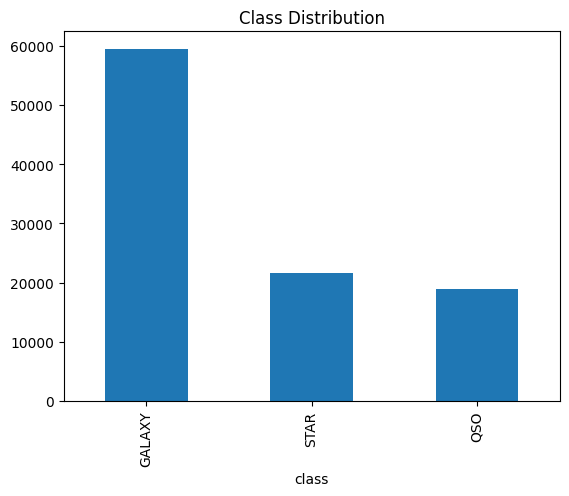

In [6]:
import matplotlib.pyplot as plt
df['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()


In [7]:
!pip install timm


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import timm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report


In [9]:
df = df.drop(columns=["obj_ID", "run_ID", "rerun_ID", "cam_col", "field_ID"])


In [10]:
le = LabelEncoder()
df["class"] = le.fit_transform(df["class"])

print(le.classes_)


['GALAXY' 'QSO' 'STAR']


In [11]:
X = df.drop("class", axis=1).values
y = df["class"].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [15]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 10
NUM_CLASSES = 3

print("Device:", DEVICE)


Device: cuda


In [13]:
import torch.nn.functional as F

class SDSSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        row = self.X[idx]

        padded = torch.nn.functional.pad(row, (0, 20 - row.shape[0]))
        img = padded.view(1, 4, 5)
        img = F.interpolate(
            img.unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return img, self.y[idx]


In [14]:
train_dataset = SDSSDataset(X_train, y_train)
test_dataset  = SDSSDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [16]:
class CNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [21]:
cnn_model = CNN().to(DEVICE)

In [22]:
vit_model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES,
    in_chans=1
).to(DEVICE)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [ ]:
swin_model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES,
    in_chans=1
).to(DEVICE)


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [17]:
def train_model(model):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{EPOCHS} Loss: {total_loss:.4f}")


In [18]:
def evaluate_model(model, name):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(DEVICE)
            preds = torch.argmax(model(x), dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(y.numpy())

    print(f"\n{name} RESULTS")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=le.classes_))


In [22]:
train_model(cnn_model)
evaluate_model(cnn_model, "CNN")


Epoch 1/10 Loss: 2067.5721
Epoch 2/10 Loss: 1987.0386
Epoch 3/10 Loss: 1877.6633
Epoch 4/10 Loss: 1762.2096
Epoch 5/10 Loss: 1698.8071
Epoch 6/10 Loss: 1653.0346
Epoch 7/10 Loss: 1612.5766
Epoch 8/10 Loss: 1572.4799
Epoch 9/10 Loss: 1539.7071
Epoch 10/10 Loss: 1509.2031

CNN RESULTS
Accuracy: 0.73115
              precision    recall  f1-score   support

      GALAXY       0.71      0.96      0.82     11889
         QSO       0.89      0.58      0.70      3792
        STAR       0.69      0.24      0.35      4319

    accuracy                           0.73     20000
   macro avg       0.76      0.59      0.62     20000
weighted avg       0.74      0.73      0.69     20000



In [23]:
train_model(vit_model)
evaluate_model(vit_model, "ViT")


Epoch 1/10 Loss: 425.3336
Epoch 2/10 Loss: 301.5887
Epoch 3/10 Loss: 283.1639
Epoch 4/10 Loss: 269.1110
Epoch 5/10 Loss: 262.3015
Epoch 6/10 Loss: 247.7509
Epoch 7/10 Loss: 245.8568
Epoch 8/10 Loss: 246.3974
Epoch 9/10 Loss: 235.4786
Epoch 10/10 Loss: 236.1602

ViT RESULTS
Accuracy: 0.96565
              precision    recall  f1-score   support

      GALAXY       0.98      0.97      0.97     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.93      1.00      0.96      4319

    accuracy                           0.97     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000



In [25]:
train_model(swin_model)
evaluate_model(swin_model, "Swin Transformer")


Epoch 1/10 Loss: 518.3218
Epoch 2/10 Loss: 338.1066
Epoch 3/10 Loss: 341.1495
Epoch 4/10 Loss: 307.1978
Epoch 5/10 Loss: 282.8514
Epoch 6/10 Loss: 277.3901
Epoch 7/10 Loss: 275.5303
Epoch 8/10 Loss: 257.4126
Epoch 9/10 Loss: 259.2022
Epoch 10/10 Loss: 250.8457

Swin Transformer RESULTS
Accuracy: 0.9728
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98     11889
         QSO       0.98      0.92      0.95      3792
        STAR       0.97      1.00      0.98      4319

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000

